# 05 — KPI & Insight Generation

**Purpose:** Define core business KPIs, detect anomalies/risk signals, and run a
structured root-cause investigation on top of the feature-engineered and
member-summary tables, per PRD Section 9 (PR11–PR12).

**Inputs:**
- `data/processed/streakforge_features.csv` (206,732 rows × 80 columns)
- `data/processed/member_behaviour_summary.csv` (16,956 rows × 33 columns, from `04_eda_and_behavioural_analysis.ipynb`)
- `data/interim/subscription_renewal_records_clean.csv` (for the AS_OF_DATE sensitivity check)

**Outputs:**
- `data/processed/kpi_summary.csv`
- `data/processed/at_risk_members.csv`
- `data/processed/branch_risk_summary.csv`
- `data/processed/activation_segment_comparison.csv`
- `data/processed/activation_cohort_trend.csv`
- `reports/root_cause_investigation_log.csv`
- `reports/figures/pr11_weekly_engagement_anomalies.png`
- `reports/figures/pr11_branch_churn_anomalies.png`
- `reports/figures/pr12_activation_cohort_trend.png`
- `reports/figures/pr12_activation_by_branch.png`

This notebook covers two PRs: PR11, PR12.

# PR11 — KPI Definition & Business Metric Design; Anomaly Detection & Risk Identification

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("../data/processed")
INTERIM_DIR = Path("../data/interim")
FIGURES_DIR = Path("../reports/figures")
REPORTS_DIR = Path("../reports")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

AS_OF_DATE = pd.Timestamp("2026-08-14")     # pipeline cutoff, unchanged from notebooks 01-04
GRACE_PERIOD_DAYS = 30

DATE_COLS = ["event_datetime", "date_of_birth", "join_date", "billing_cycle_start",
             "billing_cycle_end", "streak_start_date", "streak_end_date"]

features = pd.read_csv(PROCESSED_DIR / "streakforge_features.csv",
                        parse_dates=DATE_COLS, low_memory=False)
member_summary = pd.read_csv(PROCESSED_DIR / "member_behaviour_summary.csv",
                              parse_dates=["join_date"]).set_index("member_id")

print("features:", features.shape)
print("member_summary:", member_summary.shape)
# features: (206732, 80)
# member_summary: (16956, 33)

features: (206732, 80)
member_summary: (16956, 33)


## 11.1 KPI Definition & Business Metric Design

Every KPI below is built as a row in a reusable `kpi_id / kpi_name / category /
value / unit / definition` table rather than one-off prints, so this same
logic can be lifted directly into `src/insights.py` for the Streamlit app
(PRD Section 6) without rewriting it. Medians are used instead of means for
right-skewed spend metrics, per PR8's flag.

In [2]:
# ── 11.1 KPI table builder ───────────────────────────────────────────────
# member_summary already carries most of what we need at member grain
# (churn, recency/frequency/monetary, streak/session aggregates). A handful
# of KPIs need renewal- or streak-*episode* grain, which member_summary
# collapsed away — pulled back out of `features` via the same
# drop_duplicates(<business_key>) pattern used in PR8/PR10, so a renewal or
# streak episode is never double-counted just because it spans many events.
subs_distinct = features.drop_duplicates("renewal_id").dropna(subset=["renewal_id"])
streak_distinct = features.dropna(subset=["streak_length_days"]).drop_duplicates("streak_id")

kpi_rows = []

def add_kpi(kpi_id, name, category, value, unit, definition):
    kpi_rows.append({
        "kpi_id": kpi_id, "kpi_name": name, "category": category,
        "value": round(value, 4) if isinstance(value, (int, float, np.floating)) else value,
        "unit": unit, "definition": definition,
    })

# --- recompute the 7-day activation flag (PR10's funnel logic) once here,
#     since it isn't persisted in member_behaviour_summary.csv ---
activated = (features.loc[features["tenure_days_at_event"] <= 7]
             .groupby("member_id").size().reindex(member_summary.index).fillna(0).gt(0))
member_summary["activated_7d"] = activated

In [3]:
# --- Retention & churn ---
add_kpi("kpi_01", "Overall Churn Rate", "Retention",
        member_summary["is_churned"].mean(), "%",
        "Share of members whose latest billing cycle ended > 30d before AS_OF_DATE.")
add_kpi("kpi_02", "Overall Retention Rate", "Retention",
        1 - member_summary["is_churned"].mean(), "%",
        "1 - Overall Churn Rate.")
add_kpi("kpi_03", "Active Members", "Retention",
        (~member_summary["is_churned"]).sum(), "count",
        "Members not classified as churned as of AS_OF_DATE.")

# --- Acquisition & activation ---
add_kpi("kpi_04", "7-Day Activation Rate", "Acquisition & Activation",
        member_summary["activated_7d"].mean(), "%",
        "Share of members logging any gym/app event within 7 days of join_date.")
add_kpi("kpi_05", "Renewal Follow-Through Rate", "Acquisition & Activation",
        (member_summary["n_renewals"] >= 2).sum() / (member_summary["n_renewals"] >= 1).sum(), "%",
        "Of members who ever subscribed, the share who renewed at least once more.")

# --- Revenue ---
add_kpi("kpi_06", "Median Revenue per Member", "Revenue",
        member_summary["total_amount_paid_inr"].median(), "INR",
        "Median total ₹ paid per member (median preferred: PR8 flagged heavy right-skew).")
add_kpi("kpi_07", "Mean Revenue per Member", "Revenue",
        member_summary["total_amount_paid_inr"].mean(), "INR",
        "Mean total ₹ paid per member -- reported alongside the median to show skew.")
add_kpi("kpi_08", "Discount Utilisation Rate", "Revenue",
        subs_distinct["discount_applied"].mean(), "%",
        "Share of distinct renewal records with a discount applied.")
add_kpi("kpi_09", "Corporate Tie-Up Mix", "Revenue",
        subs_distinct["corporate_tie_up_flag"].mean(), "%",
        "Share of distinct renewal records under a corporate tie-up plan.")
add_kpi("kpi_10", "Median Plan-to-Engagement Ratio", "Revenue",
        member_summary["plan_to_engagement_ratio"].median(), "INR/session",
        "Median ₹ paid per logged gym session -- surfaces 'paying but not showing up'.")

# --- Engagement & product health ---
add_kpi("kpi_11", "Avg Weekly Session Rate", "Engagement",
        member_summary["avg_sessions_per_week_rolling_4wk"].mean(), "sessions/wk",
        "Mean of each member's trailing-4-week rolling weekly gym-session rate.")
add_kpi("kpi_12", "Avg Session Consistency Score", "Engagement",
        member_summary["session_consistency_score"].mean(), "CV",
        "Mean coefficient-of-variation of gym-session gaps (lower = more regular attendance).")
add_kpi("kpi_13", "Avg Streak Length", "Product / Streak Health",
        member_summary["avg_streak_length_days"].mean(), "days",
        "Mean of each member's own average streak length across their streak episodes.")
add_kpi("kpi_14", "Streak-Break Recovery Rate", "Product / Streak Health",
        streak_distinct["streak_break_recovery_flag"].mean(), "%",
        "Of finished streaks, the share where the member returned to the gym within 14 days.")

kpi_df = pd.DataFrame(kpi_rows)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print(kpi_df.to_string(index=False))

kpi_df.to_csv(PROCESSED_DIR / "kpi_summary.csv", index=False)
print(f"\nSaved {len(kpi_df)} KPIs to {PROCESSED_DIR / 'kpi_summary.csv'}")

kpi_id                        kpi_name                 category       value        unit                                                                           definition
kpi_01              Overall Churn Rate                Retention      0.9404           %           Share of members whose latest billing cycle ended > 30d before AS_OF_DATE.
kpi_02          Overall Retention Rate                Retention      0.0596           %                                                              1 - Overall Churn Rate.
kpi_03                  Active Members                Retention  1,011.0000       count                                  Members not classified as churned as of AS_OF_DATE.
kpi_04           7-Day Activation Rate Acquisition & Activation      0.1875           %               Share of members logging any gym/app event within 7 days of join_date.
kpi_05     Renewal Follow-Through Rate Acquisition & Activation      0.4226           %            Of members who ever subscribed, the 

### 11.1.1 Resolving the AS_OF_DATE open item (flagged in PR9/PR10)

`is_churned` was computed in PR7 off a fixed `AS_OF_DATE = 2026-08-14`, which
sits well past the dataset's actual event span (2021–2025) and produces a
~94% churn rate that swamps every segment cut tested in PR9/PR10. Per the
project's "flag, don't silently fix" convention (established in PR6), we
don't silently swap the cutoff — we compute both and report the gap.

In [4]:
# ── 11.1.1 AS_OF_DATE sensitivity check ──────────────────────────────────
subs_raw = pd.read_csv(INTERIM_DIR / "subscription_renewal_records_clean.csv",
                        parse_dates=["billing_cycle_start", "billing_cycle_end"])

DATA_AS_OF_DATE = features["event_datetime"].max()   # dataset's actual last observed activity

last_cycle_end = subs_raw.groupby("member_id")["billing_cycle_end"].max()

def churn_rate_at(as_of_date, all_member_ids):
    cutoff = as_of_date - pd.Timedelta(days=GRACE_PERIOD_DAYS)
    is_churned_alt = (last_cycle_end < cutoff).reindex(all_member_ids).fillna(True)
    return is_churned_alt.mean()

pipeline_rate = churn_rate_at(AS_OF_DATE, member_summary.index)
data_realistic_rate = churn_rate_at(DATA_AS_OF_DATE, member_summary.index)

print(f"Churn rate @ pipeline AS_OF_DATE ({AS_OF_DATE.date()}):      {pipeline_rate:.1%}")
print(f"Churn rate @ data-realistic as-of ({DATA_AS_OF_DATE.date()}): {data_realistic_rate:.1%}")

# DECISION (documented, not silently applied): `is_churned` in member_summary/
# features stays anchored to the fixed AS_OF_DATE, since it's already baked
# into every persisted downstream column and changing it here would create
# a silent inconsistency with notebooks 01-04. The data-realistic figure is
# reported as *additional context* for stakeholders reading the KPI summary,
# not as a replacement -- both numbers are added to kpi_summary.csv.
add_kpi("kpi_15", "Churn Rate (data-realistic as-of)", "Retention",
        data_realistic_rate, "%",
        f"Same is_churned logic, re-anchored to the dataset's actual max event date "
        f"({DATA_AS_OF_DATE.date()}) instead of the fixed pipeline AS_OF_DATE -- context only.")
kpi_df = pd.DataFrame(kpi_rows)
kpi_df.to_csv(PROCESSED_DIR / "kpi_summary.csv", index=False)

Churn rate @ pipeline AS_OF_DATE (2026-08-14):      94.0%
Churn rate @ data-realistic as-of (2025-10-05): 84.0%


## 11.2 Anomaly Detection & Risk Identification

Three layers, each answering a different business question:
1. **Time-series anomaly detection** — did engagement volume ever spike or
   collapse unexpectedly week-over-week?
2. **Segment-level anomaly detection** — are any gym branches statistical
   outliers on churn, independent of the platform-wide ~94% baseline?
3. **Member-level risk scoring** — which *individual* members show the
   clearest combination of risk signals right now?

Weeks flagged as engagement-volume anomalies: 14 / 249
                event_count  rolling_mean  z_score
event_datetime                                    
2022-01-09              559      318.2500   2.3300
2022-10-30              423      477.6200  -2.0900
2023-01-08             1165      688.0000   2.4100
2023-06-04              741      807.5000  -2.1600
2023-06-11              685      794.2500  -2.0500
2024-01-07             1756    1,045.8800   2.2900
2024-06-09             1013    1,173.1200  -2.1800
2024-09-08             1186    1,100.2500   2.1300
2024-11-10             1024    1,209.6200  -2.0000
2025-01-05             2116    1,493.6200   2.3800
2025-01-12             2960    1,699.8800   2.2200
2025-06-08             1516    1,698.5000  -2.1300
2025-09-14             1741    1,604.3800   2.0400
2025-10-05             3928    1,921.1200   2.4600


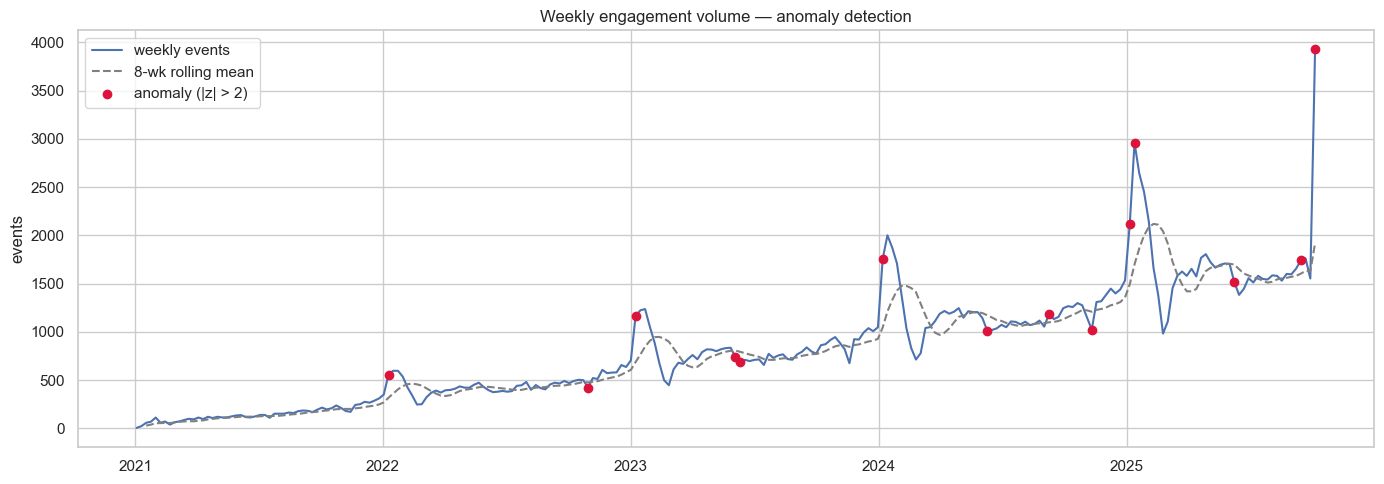

In [5]:
# ── 11.2.1 Time-series anomaly detection — weekly engagement volume ─────
weekly_events = (features.set_index("event_datetime")
                  .resample("W")["engagement_event_id"].count()
                  .rename("event_count").to_frame())

roll_window = 8  # weeks, consistent with the 8-week trailing window used elsewhere (PR7)
weekly_events["rolling_mean"] = weekly_events["event_count"].rolling(roll_window, min_periods=3).mean()
weekly_events["rolling_std"]  = weekly_events["event_count"].rolling(roll_window, min_periods=3).std()
weekly_events["z_score"] = (weekly_events["event_count"] - weekly_events["rolling_mean"]) / weekly_events["rolling_std"]
weekly_events["is_anomaly"] = weekly_events["z_score"].abs() > 2

anomalous_weeks = weekly_events.loc[weekly_events["is_anomaly"]]
print(f"Weeks flagged as engagement-volume anomalies: {len(anomalous_weeks)} / {len(weekly_events)}")
print(anomalous_weeks[["event_count", "rolling_mean", "z_score"]].round(2))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_events.index, weekly_events["event_count"], color="#4C72B0", label="weekly events")
ax.plot(weekly_events.index, weekly_events["rolling_mean"], color="grey", linestyle="--", label=f"{roll_window}-wk rolling mean")
ax.scatter(anomalous_weeks.index, anomalous_weeks["event_count"], color="crimson", zorder=5, label="anomaly (|z| > 2)")
ax.set_title("Weekly engagement volume — anomaly detection")
ax.set_ylabel("events")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr11_weekly_engagement_anomalies.png", dpi=100)
plt.show()

weekly_events.to_csv(PROCESSED_DIR / "weekly_engagement_anomalies.csv")

Branches flagged as churn-rate outliers: 0 / 40
Empty DataFrame
Columns: [gym_branch_id, members, churn_rate, activation_rate, avg_sessions_per_week, is_churn_outlier]
Index: []


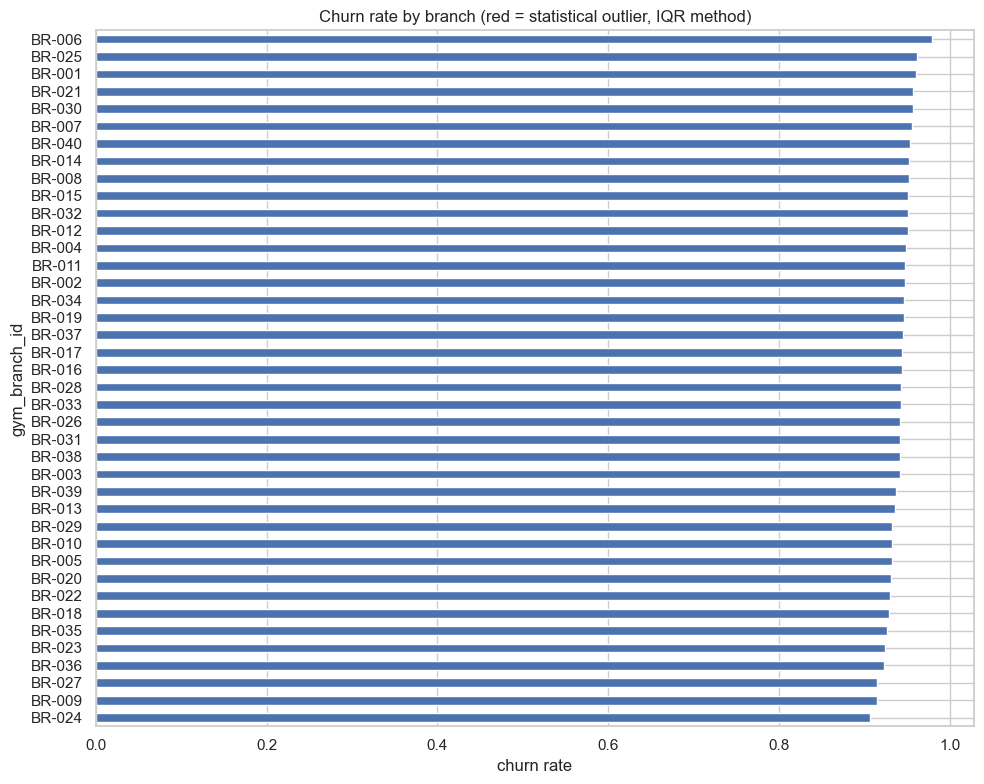

In [6]:
# ── 11.2.2 Segment-level anomaly — branch churn performance ─────────────
# gym_branch_id is a member's *home* branch (members_master), not persisted
# in member_behaviour_summary.csv (PR8's const_cols omitted it) -- pull it
# back from `features`, one row per member, and join on.
home_branch = features.drop_duplicates("member_id").set_index("member_id")["gym_branch_id"]
member_summary["gym_branch_id"] = member_summary.index.map(home_branch)

branch_stats = member_summary.groupby("gym_branch_id", observed=True).agg(
    members=("is_churned", "size"),
    churn_rate=("is_churned", "mean"),
    activation_rate=("activated_7d", "mean"),
    avg_sessions_per_week=("avg_sessions_per_week_rolling_4wk", "mean"),
).reset_index()

# IQR-based outlier flagging (same helper pattern as PR4/PR1) on churn_rate
q1, q3 = branch_stats["churn_rate"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
branch_stats["is_churn_outlier"] = ~branch_stats["churn_rate"].between(lo, hi)

flagged_branches = branch_stats.loc[branch_stats["is_churn_outlier"]].sort_values("churn_rate", ascending=False)
print(f"Branches flagged as churn-rate outliers: {len(flagged_branches)} / {len(branch_stats)}")
print(flagged_branches.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
colors = branch_stats["is_churn_outlier"].map({True: "crimson", False: "#4C72B0"})
branch_stats.sort_values("churn_rate").plot(
    kind="barh", x="gym_branch_id", y="churn_rate", ax=ax,
    color=branch_stats.sort_values("churn_rate")["is_churn_outlier"].map({True: "crimson", False: "#4C72B0"}))
ax.set_title("Churn rate by branch (red = statistical outlier, IQR method)")
ax.set_xlabel("churn rate")
ax.get_legend().remove()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr11_branch_churn_anomalies.png", dpi=100)
plt.show()

branch_stats.to_csv(PROCESSED_DIR / "branch_risk_summary.csv", index=False)

In [7]:
# ── 11.2.3 Member-level composite risk scoring ───────────────────────────
# Rule-based (no ML/clustering, per PRD scope) composite score across four
# independent risk signals, each contributing 0/1 based on quartile position
# -- mirrors the RFM quartile-bucketing pattern already used in PR10.
risk_frame = member_summary.loc[~member_summary["is_churned"]].copy()  # risk scoring only meaningful for currently-active members

risk_frame["risk_high_recency"] = risk_frame["recency_days"] > risk_frame["recency_days"].quantile(0.75)
risk_frame["risk_low_frequency"] = risk_frame["frequency_total_events"] < risk_frame["frequency_total_events"].quantile(0.25)
risk_frame["risk_negative_trend"] = risk_frame["engagement_trend_slope"] < 0   # explicitly declining, not just NaN
risk_frame["risk_paying_not_showing"] = risk_frame["plan_to_engagement_ratio"] > risk_frame["plan_to_engagement_ratio"].quantile(0.75)

risk_cols = ["risk_high_recency", "risk_low_frequency", "risk_negative_trend", "risk_paying_not_showing"]
risk_frame["risk_score"] = risk_frame[risk_cols].fillna(False).sum(axis=1)

risk_tier_bins = [-1, 0, 1, 2, 4]
risk_tier_labels = ["Low", "Moderate", "Elevated", "High"]
risk_frame["risk_tier"] = pd.cut(risk_frame["risk_score"], bins=risk_tier_bins, labels=risk_tier_labels)

print(risk_frame["risk_tier"].value_counts())

at_risk_members = (risk_frame.loc[risk_frame["risk_tier"] == "High"]
                    .sort_values("risk_score", ascending=False)
                    [["risk_score"] + risk_cols + ["recency_days", "frequency_total_events",
                                                    "engagement_trend_slope", "plan_to_engagement_ratio",
                                                    "gym_branch_id"]])
print(f"\n{len(at_risk_members)} currently-active members flagged 'High' risk (all 4 signals present)")
print(at_risk_members.head(10))

at_risk_members.to_csv(PROCESSED_DIR / "at_risk_members.csv")

risk_tier
Low         478
Moderate    410
Elevated    111
High         12
Name: count, dtype: int64

12 currently-active members flagged 'High' risk (all 4 signals present)
            risk_score  risk_high_recency  risk_low_frequency  risk_negative_trend  risk_paying_not_showing  recency_days  frequency_total_events  \
member_id                                                                                                                                           
MBR-000763           3               True               False                 True                     True           395                       9   
MBR-000273           3               True                True                False                     True           705                       1   
MBR-007323           3               True                True                False                     True           625                       1   
MBR-008985           3               True                True                False